Feature-based baselines (response-only TF-IDF + simple engineered features)

### Goal

Build a stronger feature-based baseline for hallucination detection using:
- TF-IDF over the **response** only (lexical signal),
- simple engineered numeric features (style/structure signals),
- a combined linear classifier pipeline.

This notebook assumes the earlier prompt+response baseline was evaluated in Notebook 02 and focuses on a cleaner response-only setup.

In [49]:
import sys
from pathlib import Path

# Ensure repo root is in PYTHONPATH when running from notebooks/
ROOT = Path("..").resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.features import add_numeric_feature_columns, get_numeric_feature_cols
from src.utils import evaluate_split, metrics_table


In [50]:
import re
import numpy as np
import pandas as pd

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, precision_score, recall_score

In [51]:

ROOT = Path("..")  # notebooks/ -> repo root

train_df = pd.read_csv(ROOT / "data_processed/train.csv")
val_df   = pd.read_csv(ROOT / "data_processed/val.csv")
test_df  = pd.read_csv(ROOT / "data_processed/test.csv")

print(train_df.shape, val_df.shape, test_df.shape)
train_df.head(2)


(51605, 6) (6451, 6) (6451, 6)


,id,task,prompt,response,label,context
0,qa_3453_gt,qa,Johnny Mathis Sings included a song that start...,Blake Edwards,0,The finished product included a number from B...
1,summarization_3622_hall,summarization,Usain Bolt says Tyson Gay should have been giv...,Usain Bolt and Tyson Gay are set to compete ag...,1,NaN


In [52]:
for name, df in [("train", train_df), ("val", val_df), ("test", test_df)]:
    missing = set(["prompt","response","label","task"]).difference(df.columns)
    print(name, "missing:", missing, "| label mean:", df["label"].mean())


train missing: set() | label mean: 0.4650712140296483
val missing: set() | label mean: 0.46504417919702373
test missing: set() | label mean: 0.46504417919702373


### Numeric feature extraction

We extract lightweight, interpretable numeric features from each response.
These features aim to capture stylistic patterns (e.g., length, punctuation usage, numeric content, uncertainty expressions) that may correlate with hallucinated outputs.


### Apply Features + Sanity Checks

We generate numeric feature columns for each split and run quick checks to confirm:
- no unexpected missing values,
- consistent feature columns across splits,
- shapes look reasonable before modeling.


In [53]:
train_feat = add_numeric_feature_columns(train_df, response_col="response")
val_feat   = add_numeric_feature_columns(val_df, response_col="response")
test_feat  = add_numeric_feature_columns(test_df, response_col="response")

numeric_feature_cols = get_numeric_feature_cols(train_feat)
print("Numeric feature columns:", numeric_feature_cols)

# Quick sanity checks
for name, df in [("train", train_feat), ("val", val_feat), ("test", test_feat)]:
    n_nan = df[numeric_feature_cols].isna().sum().sum()
    print(f"{name}: numeric NaN count = {n_nan}, shape={df.shape}")


Numeric feature columns: ['resp_n_chars', 'resp_n_words', 'resp_n_punct', 'resp_has_multi_excl', 'resp_has_multi_q', 'resp_has_ellipsis', 'resp_n_numbers', 'resp_n_uncertainty', 'resp_punct_per_word', 'resp_numbers_per_word']
train: numeric NaN count = 0, shape=(51605, 16)
val: numeric NaN count = 0, shape=(6451, 16)
test: numeric NaN count = 0, shape=(6451, 16)


### Sanity Check: Feature Distributions

Before training, we visualize a small subset of feature distributions to ensure:
- features are not constant (“dead features”),
- ranges are reasonable (no extreme scaling issues),
- sparse features (e.g., numbers / uncertainty terms) still have variation.


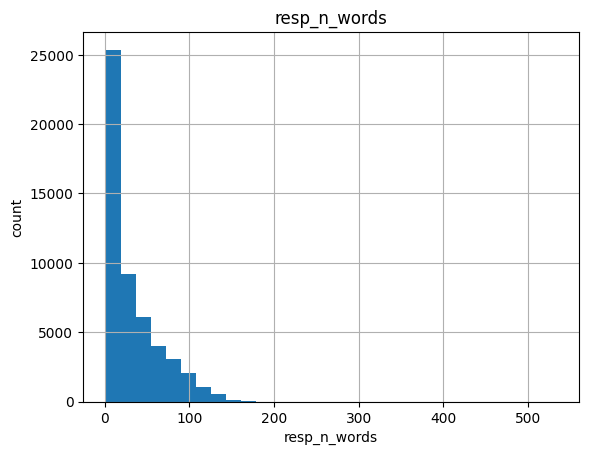

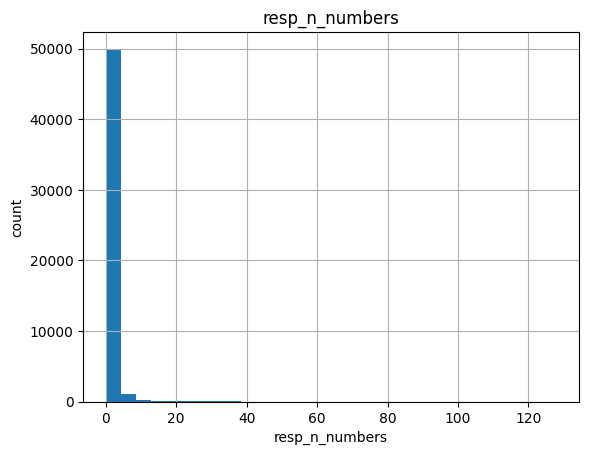

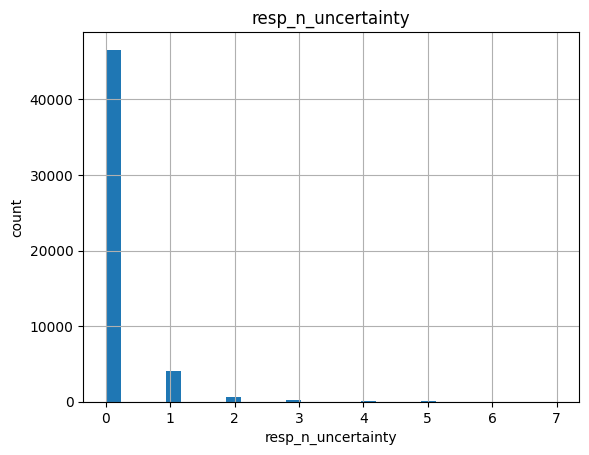

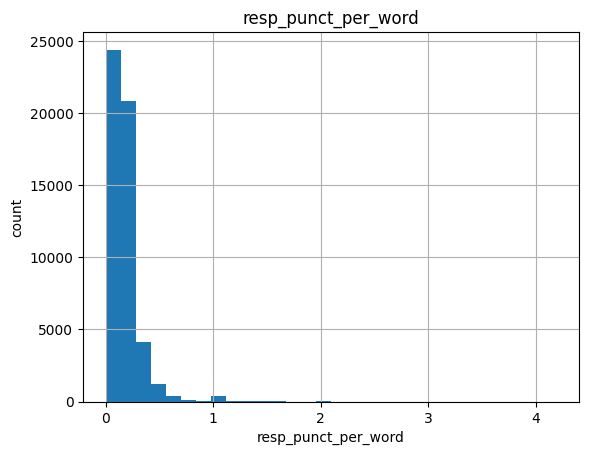

In [54]:
import matplotlib.pyplot as plt

def plot_feature_histograms(df: pd.DataFrame, cols, bins=30):
    """Quick sanity-check histograms for numeric features."""
    for col in cols:
        plt.figure()
        df[col].hist(bins=bins)
        plt.title(col)
        plt.xlabel(col)
        plt.ylabel("count")
        plt.show()

plot_cols = ["resp_n_words", "resp_n_numbers", "resp_n_uncertainty", "resp_punct_per_word"]
plot_feature_histograms(train_feat, plot_cols)


### Modeling pipeline

We construct a unified modeling pipeline using `ColumnTransformer`:
- TF-IDF is applied to the **response text only** to capture lexical information.
- Numeric features are standardized and concatenated with the TF-IDF representation.

The combined feature space is fed into a Logistic Regression classifier, serving as a strong and interpretable baseline.



In [55]:
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# Metrics
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix

# ----------------------------
# Prepare columns
# ----------------------------
numeric_feature_cols = [c for c in train_feat.columns if c.startswith("resp_")]

# ----------------------------
# Preprocessing
# ----------------------------
tfidf = TfidfVectorizer(
    lowercase=True,
    ngram_range=(1, 2),     # unigram + bigram baseline
    min_df=2,               # ignore extremely rare terms
    max_df=0.95,            # ignore extremely common terms
    sublinear_tf=True
)

preprocess = ColumnTransformer(
    transformers=[
        ("tfidf_resp", tfidf, "response"),
        ("num", StandardScaler(), numeric_feature_cols),
    ],
    remainder="drop",
    sparse_threshold=0.3    # keep sparse representation when useful
)

# ----------------------------
# Model
# ----------------------------
clf = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",  # helpful when class ratio isn't exactly 50/50
    n_jobs=-1
)

pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("clf", clf),
])

pipe


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('tfidf_resp', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers

### Training and Evaluation

We train on the fixed training split and evaluate on validation/test using Accuracy, Precision, Recall, and F1-score. F1 is emphasized because it balances false positives and false negatives, which is important for hallucination detection.

In [56]:
# ----------------------------
# Data for modeling (single source of truth)
# ----------------------------

# Ensure we are using the feature-augmented DataFrames
train_feat = add_numeric_feature_columns(train_df, response_col="response")
val_feat   = add_numeric_feature_columns(val_df, response_col="response")
test_feat  = add_numeric_feature_columns(test_df, response_col="response")

numeric_feature_cols = get_numeric_feature_cols(train_feat)

# X/y splits
X_train = train_feat
y_train = train_feat["label"].astype(int)

X_val = val_feat
y_val = val_feat["label"].astype(int)

X_test = test_feat
y_test = test_feat["label"].astype(int)

print("Shapes:", X_train.shape, X_val.shape, X_test.shape)
print("Numeric features:", len(numeric_feature_cols))


Shapes: (51605, 16) (6451, 16) (6451, 16)
Numeric features: 10


### Ablation Study

To quantify the contribution of engineered numeric features, we compare:
1) **TF-IDF(response) only**
2) **TF-IDF(response) + numeric features**

A consistent improvement indicates that the numeric features add complementary information beyond lexical content.


In [57]:
# ----------------------------
# Ablation: TF-IDF(response) only vs TF-IDF(response)+numeric
# ----------------------------

# TF-IDF only (response)
preprocess_tfidf_only = ColumnTransformer(
    transformers=[("tfidf_resp", tfidf, "response")],
    remainder="drop"
)

pipe_tfidf_only = Pipeline(steps=[
    ("preprocess", preprocess_tfidf_only),
    ("clf", LogisticRegression(max_iter=2000, class_weight="balanced")),
])

# TF-IDF + numeric (full model) - define locally to avoid relying on a fitted global `pipe`
preprocess_full = ColumnTransformer(
    transformers=[
        ("tfidf_resp", tfidf, "response"),
        ("num", StandardScaler(), numeric_feature_cols),
    ],
    remainder="drop",
    sparse_threshold=0.3
)

pipe_full = Pipeline(steps=[
    ("preprocess", preprocess_full),
    ("clf", LogisticRegression(max_iter=2000, class_weight="balanced")),
])

# Fit both
pipe_tfidf_only.fit(X_train, y_train)
pipe_full.fit(X_train, y_train)

# Evaluate on validation
val_only = evaluate_split("val (tfidf-only)", pipe_tfidf_only, X_val, y_val)
val_full = evaluate_split("val (tfidf+numeric)", pipe_full, X_val, y_val)

# Summary table
metrics_table([
    {"setting": "TF-IDF(response) only", "val_accuracy": val_only.accuracy, "val_f1": val_only.f1},
    {"setting": "TF-IDF(response) + numeric features", "val_accuracy": val_full.accuracy, "val_f1": val_full.f1},
])



val (tfidf-only) metrics:
  accuracy = 0.8224
  f1       = 0.8106
  precision= 0.8037
  recall   = 0.8177
  confusion matrix:
[[2852  599]
 [ 547 2453]]

val (tfidf+numeric) metrics:
  accuracy = 0.8228
  f1       = 0.8145
  precision= 0.7936
  recall   = 0.8367
  confusion matrix:
[[2798  653]
 [ 490 2510]]


,setting,val_accuracy,val_f1
0,TF-IDF(response) only,0.822353,0.810641
1,TF-IDF(response) + numeric features,0.822818,0.814538


### Sanity Checks (No Leakage)

We run additional checks to validate the experimental setup:
- **Train vs. validation/test gap** to assess generalization,
- **Shuffled-label test** (expected ~random performance) to rule out leakage,
- **Overlap checks** across splits to identify potential duplicates.


In [58]:
from sklearn.utils import shuffle

y_train_shuffled = shuffle(train_feat["label"].astype(int), random_state=42)

pipe_shuf = Pipeline(steps=[
    ("preprocess", preprocess),
    ("clf", LogisticRegression(max_iter=2000, class_weight="balanced", n_jobs=-1))
])

pipe_shuf.fit(train_feat, y_train_shuffled)

_ = evaluate_split("val (shuffled labels)", pipe_shuf, val_feat, val_feat["label"].astype(int))


/Users/aviv.gross/hallu-detect/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)



val (shuffled labels) metrics:
  accuracy = 0.4967
  f1       = 0.4589
  precision= 0.4588
  recall   = 0.4590
  confusion matrix:
[[1827 1624]
 [1623 1377]]


In [59]:
def overlap_rate(a: pd.Series, b: pd.Series) -> float:
    a_set = set(a.fillna("").astype(str))
    b_set = set(b.fillna("").astype(str))
    inter = a_set.intersection(b_set)
    return len(inter) / max(len(b_set), 1)

print("Response overlap train->val:", overlap_rate(train_df["response"], val_df["response"]))
print("Response overlap train->test:", overlap_rate(train_df["response"], test_df["response"]))

# Stronger check: exact (prompt, response) pairs
train_pairs = set(zip(train_df["prompt"].fillna("").astype(str), train_df["response"].fillna("").astype(str)))
val_pairs   = set(zip(val_df["prompt"].fillna("").astype(str),   val_df["response"].fillna("").astype(str)))
test_pairs  = set(zip(test_df["prompt"].fillna("").astype(str),  test_df["response"].fillna("").astype(str)))

print("Exact pair overlap train->val:", len(train_pairs & val_pairs) / max(len(val_pairs), 1))
print("Exact pair overlap train->test:", len(train_pairs & test_pairs) / max(len(test_pairs), 1))


Response overlap train->val: 0.028481012658227847
Response overlap train->test: 0.03295832673110442
Exact pair overlap train->val: 0.0
Exact pair overlap train->test: 0.0


In [60]:
# Build a consistent results table from objects we know exist
# (val_only, val_full) and compute test_full if needed.

# Compute test metrics for the full model (tfidf+numeric)
test_full = evaluate_split("test", pipe_full, X_test, y_test)

df = pd.DataFrame([
    {"model": "TF-IDF(response) only",      **val_only.as_dict()},
    {"model": "TF-IDF(response)+numeric",   **val_full.as_dict()},
    {"model": "TF-IDF(response)+numeric",   **test_full.as_dict()},
])

df[["model", "split", "accuracy", "f1", "precision", "recall"]]



test metrics:
  accuracy = 0.8250
  f1       = 0.8168
  precision= 0.7960
  recall   = 0.8387
  confusion matrix:
[[2806  645]
 [ 484 2516]]


,model,split,accuracy,f1,precision,recall
0,TF-IDF(response) only,val (tfidf-only),0.822353,0.810641,0.803735,0.817667
1,TF-IDF(response)+numeric,val (tfidf+numeric),0.822818,0.814538,0.793550,0.836667
2,TF-IDF(response)+numeric,test,0.824988,0.816751,0.795951,0.838667


### Summary and discussion

This notebook evaluated a feature-based baseline for hallucination detection using response-only representations.

**Baseline reference:**  
An earlier TF-IDF baseline using both prompt and response text was evaluated in **Notebook 02**, yielding near-random performance (≈0.49 accuracy / F1 on validation).
That experiment is not reproduced here.

By restricting the representation to the generated response and combining lexical (TF-IDF) and stylistic (numeric) features, we observe a substantial and stable improvement in performance.

An ablation study shows that numeric features provide a small but consistent gain over TF-IDF alone, indicating that stylistic cues add complementary information beyond lexical content.

Additional sanity checks (train–validation gap, shuffled labels, overlap analysis) confirm that the results are not driven by data leakage.
